In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# from sklearn.linear_model import LinearRegression
# model = LinearRegression()

In [3]:
# from sklearn import linear_model
# model = linear_model.LinearRegression()

In [4]:
# import sklearn
# model = sklearn.linear_model.LinearRegression()

In [2]:
data = pd.read_csv('Advertising.csv')

In [3]:
data.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
data = data[['TV', 'radio', 'newspaper', 'sales']]

In [5]:
data.shape

(200, 4)

In [6]:
data.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [7]:
data.isnull().sum()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

In [11]:
#Normalization
#Standardization

In [9]:
data.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


Model 1

In [10]:
X = data[['TV', 'radio', 'newspaper']]
y = data['sales']

In [11]:
#OLS - oridnary least square
import statsmodels.api as sm
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  sales   R-squared (uncentered):                   0.982
Model:                            OLS   Adj. R-squared (uncentered):              0.982
Method:                 Least Squares   F-statistic:                              3566.
Date:                Sat, 29 Nov 2025   Prob (F-statistic):                   2.43e-171
Time:                        10:31:59   Log-Likelihood:                         -423.54
No. Observations:                 200   AIC:                                      853.1
Df Residuals:                     197   BIC:                                      863.0
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
TV             0.0538      0.001     40.507      0.000       0.051       0.056
radio          0.2222      0.009     23.595      0.000       0.204       0.241
newspaper      0.0168      0.007      2.517      0.013       0.004       0.030
==============================================================================
Omnibus:                        5.982   Durbin-Watson:                   2.038
Prob(Omnibus):                  0.050   Jarque-Bera (JB):                7.039
Skew:                          -0.232   Prob(JB):                       0.0296
Kurtosis:                       3.794   Cond. No.                         12.6
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# y = mX + C

# y = m1X1 + m2X2 + m3X3 + C

# Sales ~ m1('TV') + m2('Radio') + m3('Newspaper') + C

# sales ~ 0.04701415*TV + 0.18136082*Radio + 0.00629805*Newspaper

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50)

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
slope = model.coef_
intercept = model.intercept_

slope, intercept

(array([0.0475501 , 0.18088015, 0.00629805]), 2.709489908691566)

In [15]:
y_predicted = model.predict(X_test)

In [16]:
result = pd.DataFrame()
result['xtest - tv'] = X_test['TV'].copy()
result['xtest - radio'] = X_test['radio'].copy()
result['xtest - newspaper'] = X_test['newspaper'].copy()
result['ytest'] = y_test.copy()
result['ypred'] = y_predicted.copy()

In [17]:
result.head()

,xtest - tv,xtest - radio,xtest - newspaper,ytest,ypred
112,175.7,15.4,2.4,14.1,13.864713
165,234.5,3.4,84.8,11.9,15.009056
12,23.8,35.1,65.9,9.2,10.605117
73,129.4,5.7,31.3,11.0,10.090619
144,96.2,14.8,38.9,11.4,10.205830


In [18]:
from sklearn import metrics
print('MAE : ', metrics.mean_absolute_error(y_test,y_predicted))
print('MSE : ', metrics.mean_squared_error(y_test,y_predicted))
print('RMSE : ', np.sqrt(metrics.mean_squared_error(y_test,y_predicted)))
print('R-Squared : ', (metrics.r2_score(y_test,y_predicted))*100)

MAE :  1.234991924719904
MSE :  2.622772900751398
RMSE :  1.6194977310115004
R-Squared :  85.9057555097746


Model2

/opt/anaconda3/lib/python3.12/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


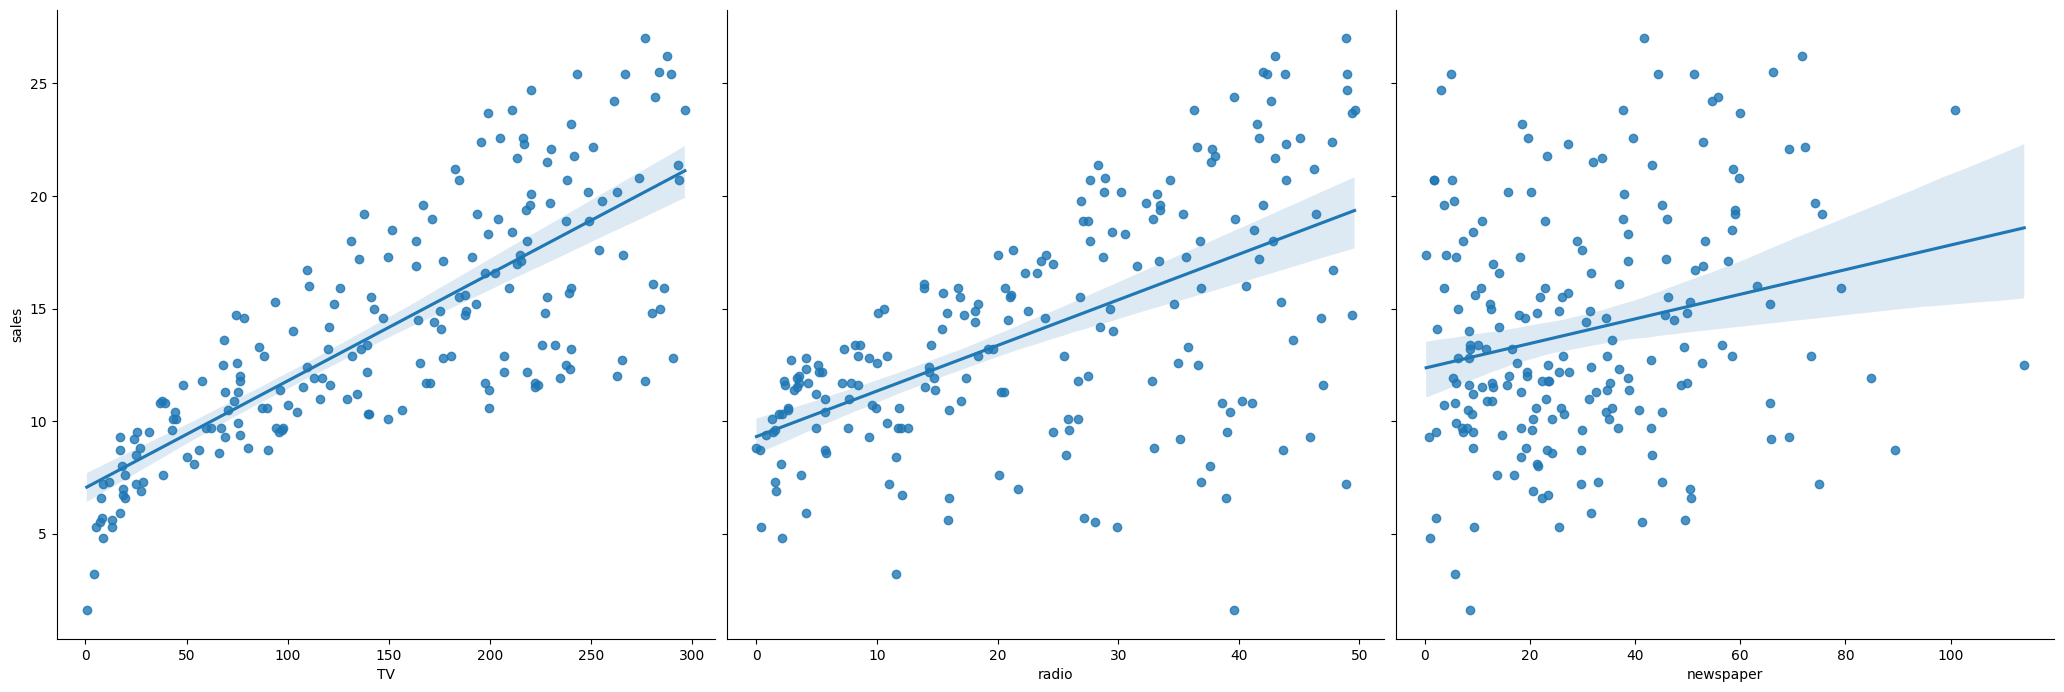

In [19]:
sns.pairplot(data, x_vars = ['TV', 'radio', 'newspaper'], y_vars='sales',size=7, kind='reg')

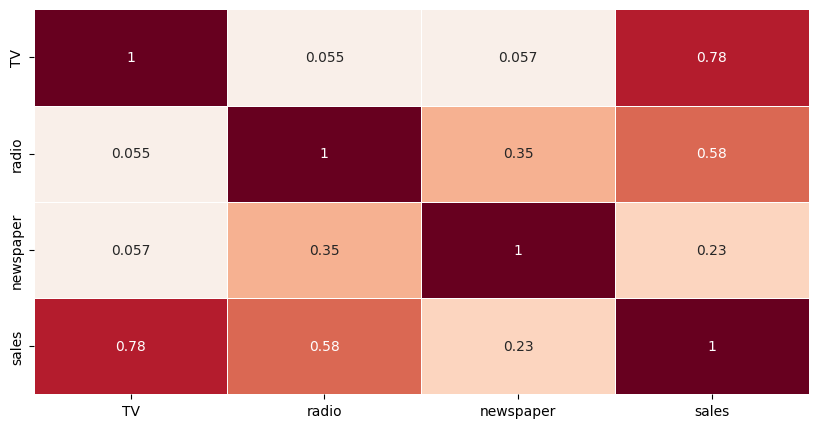

In [20]:
plt.figure(figsize=(10,5))
sns.heatmap(data.corr(),
            annot=True,
            linewidths=.5,
            center=0,
            cbar=False,
            cmap='RdBu_r')
plt.show()

In [21]:
X = data[['TV', 'radio']]
y = data['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50)

In [22]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
y_predicted = model.predict(X_test)

In [24]:
mse = mean_squared_error(y_test, y_predicted)
mae = mean_absolute_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)

mse, mae, r2

(2.50427562039, 1.198960352559236, 0.8654253562915201)

In [25]:
slope = model.coef_
intercept = model.intercept_

slope, intercept

(array([0.047571  , 0.18426024]), 2.8073696977247735)

In [26]:
len(y_predicted), len(y_test)

(60, 60)

In [27]:
y_predicted

array([14.00320204, 14.589254  , 10.40709381, 10.01334045, 10.1107514 ,
       18.30088465, 15.43323683,  3.60342679, 20.60016862, 11.70652503,
       14.97036247, 12.9410569 , 21.20978689, 14.34847748, 15.95869642,
       16.92262077, 10.11124668, 16.78182699,  9.62526283, 12.46285875,
       16.83830481, 10.1299488 ,  8.09272198, 14.0136449 , 21.15267323,
       14.26080663,  7.16306617,  7.61787873, 15.47271257, 13.60320573,
       15.03876399, 10.1730438 , 11.66349194, 16.50066281,  6.58920229,
        9.6877075 , 13.1470144 , 20.61096621,  9.12983169, 11.36154242,
        7.32333844, 24.41197947,  9.77742812, 18.27141339, 16.54950047,
       12.25951993, 12.34118374, 15.95755358,  8.84592   ,  7.70015163,
       12.1657065 , 12.06417428, 14.17947911, 10.5870755 , 17.40270468,
       16.52681263, 16.39406394,  3.50425389, 23.1055841 , 12.77660816])

In [55]:
y_test

112    14.1
165    11.9
12      9.2
73     11.0
144    11.4
20     18.0
199    13.4
8       4.8
39     21.5
88     12.9
81     12.3
197    12.8
69     22.3
160    14.4
25     12.0
99     17.2
151    11.6
23     15.5
138     9.6
159    12.9
89     16.7
82     11.3
24      9.7
174    11.5
137    20.8
83     13.6
107     8.7
34      9.5
97     15.5
167    12.2
123    15.2
157    10.1
75      8.7
152    16.6
117     9.4
149    10.1
63     14.0
54     20.2
125    10.6
80     11.8
170     8.4
183    26.2
38     10.1
153    19.0
40     16.6
190    10.8
177    11.7
131    12.7
13      9.7
121     7.0
1      10.4
116    12.2
100    11.7
166     8.0
168    17.1
48     14.8
178    11.8
108     5.3
61     24.2
16     12.5
Name: sales, dtype: float64

In [56]:
dataDF = pd.DataFrame({'y_test': y_test, 'y_predicted':pd.Series(y_predicted)})
dataDF

,y_test,y_predicted
0,NaN,14.003202
1,10.4,14.589254
2,NaN,10.407094
3,NaN,10.013340
4,NaN,10.110751
...,...,...
178,11.8,NaN
183,26.2,NaN
190,10.8,NaN
197,12.8,NaN


In [57]:
data.columns

Index(['TV', 'radio', 'newspaper', 'sales'], dtype='object')

In [28]:
x = data[['TV', 'radio']]
y = data['sales']

In [29]:
# model 3:
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=2)
X_poly = poly_reg.fit_transform(X)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.3, random_state=50)

In [31]:
poly_model = LinearRegression()
poly_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
y_predicted = poly_model.predict(X_test)

In [33]:
mse = mean_squared_error(y_test, y_predicted)
mae = mean_absolute_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)
mse, mae, r2

(0.2479808203541122, 0.4109229974936261, 0.9866740185169818)